In [1]:
# Cell 1 — Imports and Database Connection
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

DB_HOST     = os.getenv("DB_HOST", "localhost")
DB_PORT     = os.getenv("DB_PORT", "5433")
DB_NAME     = os.getenv("DB_NAME", "nifty100")
DB_USER     = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres123")

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

# Test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM dim_company"))
    print(f"Connected! Companies in warehouse: {result.scalar()}")

Connected! Companies in warehouse: 92


In [2]:
# Cell 2 — Load all financial data from warehouse
print("Loading data from PostgreSQL...")

# Profit & Loss data
df_pl = pd.read_sql("""
    SELECT 
        fpl.symbol,
        fpl.year_id,
        dy.year_label,
        dy.fiscal_year,
        dy.sort_order,
        fpl.sales,
        fpl.net_profit,
        fpl.operating_profit,
        fpl.opm_pct,
        fpl.interest,
        fpl.eps,
        fpl.dividend_payout,
        fpl.net_profit_margin_pct,
        fpl.interest_coverage
    FROM fact_profit_loss fpl
    JOIN dim_year dy ON fpl.year_id = dy.year_id
    WHERE dy.is_ttm = FALSE
    ORDER BY fpl.symbol, dy.sort_order
""", engine)

# Balance Sheet data
df_bs = pd.read_sql("""
    SELECT 
        fbs.symbol,
        fbs.year_id,
        dy.fiscal_year,
        dy.sort_order,
        fbs.borrowings,
        fbs.equity_capital,
        fbs.reserves,
        fbs.total_assets,
        fbs.debt_to_equity,
        fbs.equity_ratio
    FROM fact_balance_sheet fbs
    JOIN dim_year dy ON fbs.year_id = dy.year_id
    WHERE dy.is_ttm = FALSE
    ORDER BY fbs.symbol, dy.sort_order
""", engine)

# Cash Flow data
df_cf = pd.read_sql("""
    SELECT 
        fcf.symbol,
        fcf.year_id,
        dy.fiscal_year,
        dy.sort_order,
        fcf.operating_activity,
        fcf.free_cash_flow,
        fcf.net_cash_flow
    FROM fact_cash_flow fcf
    JOIN dim_year dy ON fcf.year_id = dy.year_id
    WHERE dy.is_ttm = FALSE
    ORDER BY fcf.symbol, dy.sort_order
""", engine)

# Company info
df_company = pd.read_sql("""
    SELECT dc.symbol, dc.company_name, ds.sector_name
    FROM dim_company dc
    LEFT JOIN dim_sector ds ON dc.sector_id = ds.sector_id
""", engine)

print(f"Profit & Loss rows: {len(df_pl)}")
print(f"Balance Sheet rows: {len(df_bs)}")
print(f"Cash Flow rows:     {len(df_cf)}")
print(f"Companies:          {len(df_company)}")

Loading data from PostgreSQL...
Profit & Loss rows: 1073
Balance Sheet rows: 1140
Cash Flow rows:     1056
Companies:          92


In [3]:
# Cell 3 — Build company-level feature matrix
# For each company, compute average metrics across all years
# These become the inputs to our health scoring model

print("Building company feature matrix...")

# ── Profitability features (from P&L) ──
prof_features = df_pl.groupby("symbol").agg(
    avg_opm_pct          = ("opm_pct",               "mean"),
    avg_net_margin       = ("net_profit_margin_pct",  "mean"),
    avg_interest_coverage= ("interest_coverage",      "mean"),
    avg_eps              = ("eps",                    "mean"),
    years_profitable     = ("net_profit",             lambda x: (x > 0).sum()),
).reset_index()

# ── Revenue growth features ──
# Get first and last year sales per company to compute CAGR
pl_sorted = df_pl.sort_values(["symbol", "sort_order"])
first_sales = pl_sorted.groupby("symbol").first()[["sales", "fiscal_year"]].rename(
    columns={"sales": "first_sales", "fiscal_year": "first_year"})
last_sales  = pl_sorted.groupby("symbol").last()[["sales", "fiscal_year"]].rename(
    columns={"sales": "last_sales", "fiscal_year": "last_year"})

growth_df = first_sales.join(last_sales)
growth_df["years"] = growth_df["last_year"] - growth_df["first_year"]
growth_df["revenue_cagr"] = np.where(
    (growth_df["years"] > 0) & (growth_df["first_sales"] > 0),
    ((growth_df["last_sales"] / growth_df["first_sales"]) ** (1 / growth_df["years"]) - 1) * 100,
    np.nan
)
growth_df = growth_df[["revenue_cagr"]].reset_index()

# ── Leverage features (from Balance Sheet) ──
lev_features = df_bs.groupby("symbol").agg(
    avg_debt_to_equity = ("debt_to_equity", "mean"),
    avg_equity_ratio   = ("equity_ratio",   "mean"),
    latest_dte         = ("debt_to_equity", "last"),
).reset_index()

# ── Cash flow features ──
cf_features = df_cf.groupby("symbol").agg(
    avg_free_cash_flow    = ("free_cash_flow",    "mean"),
    avg_operating_cf      = ("operating_activity","mean"),
    years_positive_fcf    = ("free_cash_flow",    lambda x: (x > 0).sum()),
).reset_index()

# ── Dividend features ──
div_features = df_pl.groupby("symbol").agg(
    avg_dividend_payout  = ("dividend_payout", "mean"),
    years_paid_dividend  = ("dividend_payout", lambda x: (x > 0).sum()),
).reset_index()

# ── Merge all features ──
features = df_company[["symbol", "company_name", "sector_name"]].copy()
features = features.merge(prof_features,  on="symbol", how="left")
features = features.merge(growth_df,      on="symbol", how="left")
features = features.merge(lev_features,   on="symbol", how="left")
features = features.merge(cf_features,    on="symbol", how="left")
features = features.merge(div_features,   on="symbol", how="left")

print(f"Feature matrix shape: {features.shape}")
print(f"Columns: {list(features.columns)}")
print(features.head(3))

Building company feature matrix...
Feature matrix shape: (92, 17)
Columns: ['symbol', 'company_name', 'sector_name', 'avg_opm_pct', 'avg_net_margin', 'avg_interest_coverage', 'avg_eps', 'years_profitable', 'revenue_cagr', 'avg_debt_to_equity', 'avg_equity_ratio', 'latest_dte', 'avg_free_cash_flow', 'avg_operating_cf', 'years_positive_fcf', 'avg_dividend_payout', 'years_paid_dividend']
       symbol                                       company_name sector_name  \
0  ASIANPAINT  Asian Paints\nIndian Multi-National Paint and ...      Paints   
1        ATGL                                Adani Total Gas Ltd      Energy   
2  BAJAJ-AUTO                                     Bajaj Auto Ltd        Auto   

   avg_opm_pct  avg_net_margin  avg_interest_coverage     avg_eps  \
0    18.833333       12.395000              50.832500   26.166667   
1    28.142857       17.115714              10.825714    4.571429   
2    18.666667       16.957500            2264.580833  164.833333   

   years_profi

In [4]:
# Cell 4 — Health Scoring Model
# Score each company 0-100 using percentile ranking
# Weights: Profitability 25%, Growth 20%, Leverage 20%, 
#          Cash Flow 15%, Dividends 10%, Trend 10%

print("Computing health scores...")

def percentile_rank(series):
    """
    Convert a series to percentile ranks (0-100).
    Higher value = higher percentile = better score.
    Handles NaN by leaving them as NaN.
    """
    return series.rank(pct=True, na_option='keep') * 100

def percentile_rank_inverse(series):
    """
    Inverse percentile rank — lower value = higher score.
    Used for debt metrics where lower debt = better.
    """
    return (1 - series.rank(pct=True, na_option='keep')) * 100

df = features.copy()

# ── 1. PROFITABILITY SCORE (25%) ──
# Higher OPM%, net margin, interest coverage = better
df["p_opm"]      = percentile_rank(df["avg_opm_pct"])
df["p_margin"]   = percentile_rank(df["avg_net_margin"])
df["p_coverage"] = percentile_rank(df["avg_interest_coverage"].clip(upper=500))
df["p_profit_yrs"] = percentile_rank(df["years_profitable"])

df["profitability_score"] = (
    df["p_opm"]        * 0.35 +
    df["p_margin"]     * 0.35 +
    df["p_coverage"]   * 0.20 +
    df["p_profit_yrs"] * 0.10
)

# ── 2. GROWTH SCORE (20%) ──
df["p_rev_cagr"] = percentile_rank(df["revenue_cagr"])
df["p_eps"]      = percentile_rank(df["avg_eps"].clip(upper=1000))

df["growth_score"] = (
    df["p_rev_cagr"] * 0.60 +
    df["p_eps"]      * 0.40
)

# ── 3. LEVERAGE SCORE (20%) ──
# Lower debt = better, so inverse rank
df["p_dte"]    = percentile_rank_inverse(df["avg_debt_to_equity"].clip(upper=20))
df["p_eq_ratio"] = percentile_rank(df["avg_equity_ratio"])

df["leverage_score"] = (
    df["p_dte"]      * 0.60 +
    df["p_eq_ratio"] * 0.40
)

# ── 4. CASH FLOW SCORE (15%) ──
df["p_fcf"]      = percentile_rank(df["avg_free_cash_flow"])
df["p_op_cf"]    = percentile_rank(df["avg_operating_cf"])
df["p_fcf_yrs"]  = percentile_rank(df["years_positive_fcf"])

df["cashflow_score"] = (
    df["p_fcf"]     * 0.40 +
    df["p_op_cf"]   * 0.40 +
    df["p_fcf_yrs"] * 0.20
)

# ── 5. DIVIDEND SCORE (10%) ──
df["p_div_payout"] = percentile_rank(df["avg_dividend_payout"])
df["p_div_yrs"]    = percentile_rank(df["years_paid_dividend"])

df["dividend_score"] = (
    df["p_div_payout"] * 0.50 +
    df["p_div_yrs"]    * 0.50
)

# ── 6. TREND SCORE (10%) ──
# Companies with high revenue CAGR and consistent profitability
df["trend_score"] = (
    df["p_rev_cagr"]    * 0.50 +
    df["p_profit_yrs"]  * 0.50
)

# ── OVERALL SCORE (weighted sum) ──
df["overall_score"] = (
    df["profitability_score"] * 0.25 +
    df["growth_score"]        * 0.20 +
    df["leverage_score"]      * 0.20 +
    df["cashflow_score"]      * 0.15 +
    df["dividend_score"]      * 0.10 +
    df["trend_score"]         * 0.10
)

# ── HEALTH LABEL ──
def assign_label(score):
    if pd.isna(score):
        return "UNKNOWN"
    elif score >= 85:
        return "EXCELLENT"
    elif score >= 70:
        return "GOOD"
    elif score >= 50:
        return "AVERAGE"
    elif score >= 35:
        return "WEAK"
    else:
        return "POOR"

df["health_label"] = df["overall_score"].apply(assign_label)

# Show results
result_cols = ["symbol", "company_name", "overall_score", 
               "profitability_score", "growth_score", "leverage_score",
               "cashflow_score", "dividend_score", "trend_score", "health_label"]

results = df[result_cols].sort_values("overall_score", ascending=False).reset_index(drop=True)
print(results.head(20).to_string())

Computing health scores...
        symbol                                                                 company_name  overall_score  profitability_score  growth_score  leverage_score  cashflow_score  dividend_score  trend_score health_label
0          TCS                                                Tata Consultancy Services Ltd      79.181826            78.219661     71.705686       82.197802       95.164835       82.065217    63.649666         GOOD
1   BAJAJHLDNG                                              Bajaj Holdings & Investment Ltd      76.751941            87.455208     82.212136       98.241758       41.538462       56.521739    69.144171         GOOD
2         INFY                                                                  Infosys Ltd      75.050854            76.313306     65.394171       84.395604       88.791209       63.858696    63.100215         GOOD
3         LTIM                                                              LTIMindtree Ltd      73.316412   

In [5]:
# Cell 5 — Save health scores to PostgreSQL warehouse
from datetime import datetime

print("Saving health scores to PostgreSQL...")

# Prepare the scores dataframe for insertion
scores_to_insert = df[["symbol", "overall_score", "profitability_score", 
                         "growth_score", "leverage_score", "cashflow_score",
                         "dividend_score", "trend_score", "health_label"]].copy()

scores_to_insert["computed_at"] = datetime.now()

# Round all scores to 2 decimal places
score_cols = ["overall_score", "profitability_score", "growth_score", 
              "leverage_score", "cashflow_score", "dividend_score", "trend_score"]
scores_to_insert[score_cols] = scores_to_insert[score_cols].round(2)

count = 0
with engine.connect() as conn:
    for _, row in scores_to_insert.iterrows():
        conn.execute(text("""
            INSERT INTO fact_ml_scores (
                symbol, computed_at, overall_score,
                profitability_score, growth_score, leverage_score,
                cashflow_score, dividend_score, trend_score, health_label
            ) VALUES (
                :symbol, :computed_at, :overall_score,
                :profitability_score, :growth_score, :leverage_score,
                :cashflow_score, :dividend_score, :trend_score, :health_label
            )
        """), {
            "symbol"              : row["symbol"],
            "computed_at"         : row["computed_at"],
            "overall_score"       : row["overall_score"],
            "profitability_score" : row["profitability_score"],
            "growth_score"        : row["growth_score"],
            "leverage_score"      : row["leverage_score"],
            "cashflow_score"      : row["cashflow_score"],
            "dividend_score"      : row["dividend_score"],
            "trend_score"         : row["trend_score"],
            "health_label"        : row["health_label"],
        })
        count += 1
    conn.commit()

print(f"Saved {count} company health scores to fact_ml_scores")

# Verify
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM fact_ml_scores"))
    print(f"Total rows in fact_ml_scores: {result.scalar()}")

Saving health scores to PostgreSQL...
Saved 92 company health scores to fact_ml_scores
Total rows in fact_ml_scores: 92


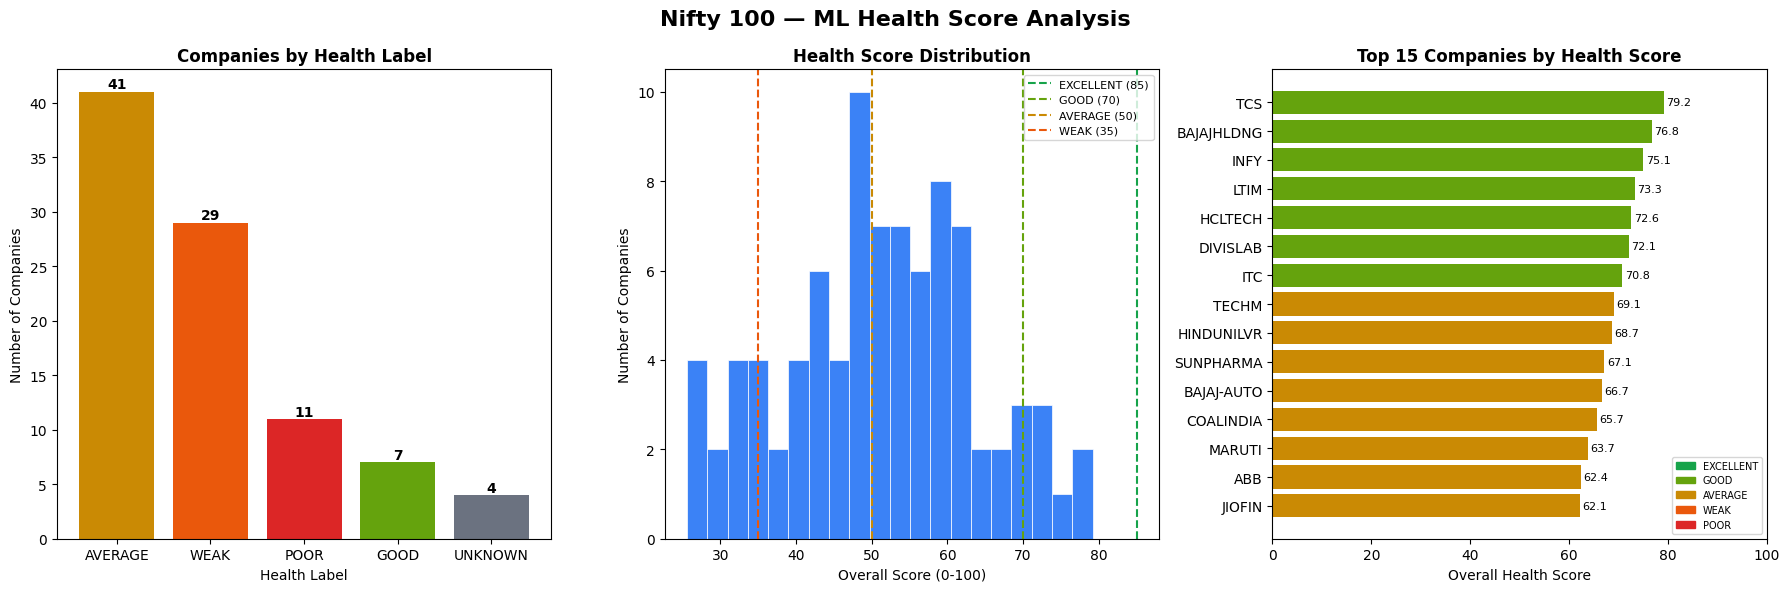

Chart saved!


In [6]:
# Cell 6 — Visualize Health Score Distribution
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Nifty 100 — ML Health Score Analysis", fontsize=16, fontweight='bold')

# ── Chart 1: Health Label Distribution ──
label_colors = {
    "EXCELLENT": "#16a34a",
    "GOOD":      "#65a30d",
    "AVERAGE":   "#ca8a04",
    "WEAK":      "#ea580c",
    "POOR":      "#dc2626",
    "UNKNOWN":   "#6b7280",
}

label_counts = results["health_label"].value_counts()
colors = [label_colors.get(l, "#6b7280") for l in label_counts.index]

axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title("Companies by Health Label", fontweight='bold')
axes[0].set_xlabel("Health Label")
axes[0].set_ylabel("Number of Companies")
for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, count + 0.3, str(count), ha='center', fontweight='bold')

# ── Chart 2: Score Distribution Histogram ──
axes[1].hist(results["overall_score"].dropna(), bins=20, 
             color="#3b82f6", edgecolor="white", linewidth=0.5)
axes[1].set_title("Health Score Distribution", fontweight='bold')
axes[1].set_xlabel("Overall Score (0-100)")
axes[1].set_ylabel("Number of Companies")
axes[1].axvline(x=85, color="#16a34a", linestyle="--", label="EXCELLENT (85)")
axes[1].axvline(x=70, color="#65a30d", linestyle="--", label="GOOD (70)")
axes[1].axvline(x=50, color="#ca8a04", linestyle="--", label="AVERAGE (50)")
axes[1].axvline(x=35, color="#ea580c", linestyle="--", label="WEAK (35)")
axes[1].legend(fontsize=8)

# ── Chart 3: Top 15 Companies by Score ──
top15 = results.head(15)
bar_colors = [label_colors.get(l, "#6b7280") for l in top15["health_label"]]
bars = axes[2].barh(top15["symbol"][::-1], top15["overall_score"][::-1], color=bar_colors[::-1])
axes[2].set_title("Top 15 Companies by Health Score", fontweight='bold')
axes[2].set_xlabel("Overall Health Score")
axes[2].set_xlim(0, 100)

# Add score labels
for bar, score in zip(bars, top15["overall_score"][::-1]):
    axes[2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{score:.1f}", va='center', fontsize=8)

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in label_colors.items() if k != "UNKNOWN"]
axes[2].legend(handles=patches, loc='lower right', fontsize=7)

plt.tight_layout()
plt.savefig('../data/clean/health_scores_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")